# Module 4: Frozen RoBERTa Embedding Baseline

**Question:** Can a fully frozen RoBERTa-base encoder plus a linear classifier outperform
the leakage-safe TF-IDF baseline on 77 banking intents?

**Evidence requirements**

- pin and hash the encoder snapshot;
- prove that all 124,055,040 encoder parameters remain frozen;
- extract train and validation embeddings before any test embedding;
- record validation-driven search amendments before test access;
- compare models on identical test source indices without persisting messages.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current = Path.cwd().resolve()
PROJECT_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / 'pyproject.toml').exists()
)
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
PROJECT_ROOT.name


'governed-banking-intent-router'

## Validate the complete evidence chain

These checks bind the reports to the dataset manifest, configuration, implementation, pinned
model files, selection lock and index-aligned predictions. They do not load message text.


In [2]:
from governed_banking.data import sha256_file, stable_json_sha256, validate_manifest
from governed_banking.frozen_baseline import (
    FrozenBaselineConfig,
    validate_frozen_evaluation_artifact,
    validate_frozen_selection_artifact,
)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'frozen_roberta.yaml'
MANIFEST_PATH = PROJECT_ROOT / 'data/manifests/banking77-seed-42.json'
REPORT_DIR = PROJECT_ROOT / 'reports/frozen-roberta'
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
selection = json.loads((REPORT_DIR / 'selection.json').read_text(encoding='utf-8'))
evaluation = json.loads((REPORT_DIR / 'test.json').read_text(encoding='utf-8'))
extraction = json.loads(
    (REPORT_DIR / 'embedding-extraction.json').read_text(encoding='utf-8')
)
comparison = json.loads(
    (REPORT_DIR / 'paired-vs-tfidf.json').read_text(encoding='utf-8')
)
tfidf = json.loads(
    (PROJECT_ROOT / 'reports/baseline/tfidf-logreg-test.json').read_text(
        encoding='utf-8'
    )
)
validate_manifest(manifest)
config = FrozenBaselineConfig.from_yaml(CONFIG_PATH)


In [3]:
implementation_sha256 = {
    'baseline.py': sha256_file(PROJECT_ROOT / 'src/governed_banking/baseline.py'),
    'data.py': sha256_file(PROJECT_ROOT / 'src/governed_banking/data.py'),
    'device.py': sha256_file(PROJECT_ROOT / 'src/governed_banking/device.py'),
    'frozen_baseline.py': sha256_file(
        PROJECT_ROOT / 'src/governed_banking/frozen_baseline.py'
    ),
    'run_frozen_roberta_baseline.py': sha256_file(
        PROJECT_ROOT / 'scripts/run_frozen_roberta_baseline.py'
    ),
}
model_hashes = selection['encoder']['files_sha256']
validate_frozen_selection_artifact(
    selection,
    dataset_manifest_sha256=manifest['manifest_sha256'],
    config_sha256=sha256_file(CONFIG_PATH),
    implementation_sha256=implementation_sha256,
    model_files_sha256=model_hashes,
)
validate_frozen_evaluation_artifact(
    evaluation,
    selection_sha256=selection['selection_sha256'],
    dataset_manifest_sha256=manifest['manifest_sha256'],
    config_sha256=sha256_file(CONFIG_PATH),
    implementation_sha256=implementation_sha256,
    model_files_sha256=model_hashes,
)
extraction_body = dict(extraction)
assert stable_json_sha256(
    {key: value for key, value in extraction_body.items() if key != 'evidence_sha256'}
) == extraction['evidence_sha256']
comparison_body = dict(comparison)
assert stable_json_sha256(
    {key: value for key, value in comparison_body.items() if key != 'comparison_sha256'}
) == comparison['comparison_sha256']
print('Module 4 evidence chain validated.')


Module 4 evidence chain validated.


## Registered search and amendments

The initial validation sweep ended at its regularisation boundary. The search was extended
logarithmically while the test split and test embeddings remained inaccessible. Round 4 was
declared final; its interior winner became the lock.


In [4]:
candidate_results = pd.DataFrame(
    [
        {
            'rank': result['validation_rank'],
            'candidate': result['candidate_name'],
            'pooling': result['candidate']['pooling'],
            'C': result['candidate']['c_value'],
            'macro_f1': result['metrics']['macro_f1'],
            'accuracy': result['metrics']['accuracy'],
            'log_loss': result['metrics']['log_loss'],
            'converged': result['converged'],
        }
        for result in selection['candidate_results']
    ]
).sort_values('rank')
candidate_results


,rank,candidate,pooling,C,macro_f1,accuracy,log_loss,converged
0,1,mean_c1024,mean,1024.0,0.882272,0.879414,0.454246,True
1,2,mean_c256,mean,256.0,0.881768,0.878748,0.538137,True
2,3,mean_c4096,mean,4096.0,0.881098,0.877415,0.454085,True
3,4,mean_c64,mean,64.0,0.858450,0.856096,0.787646,True
4,5,mean_c16,mean,16.0,0.796658,0.807462,1.346936,True
5,6,mean_c4,mean,4.0,0.655677,0.699534,2.398628,True
6,7,mean_c1,mean,1.0,0.445841,0.511659,3.542243,True
7,8,cls_c1,cls,1.0,0.016220,0.047968,4.244529,True


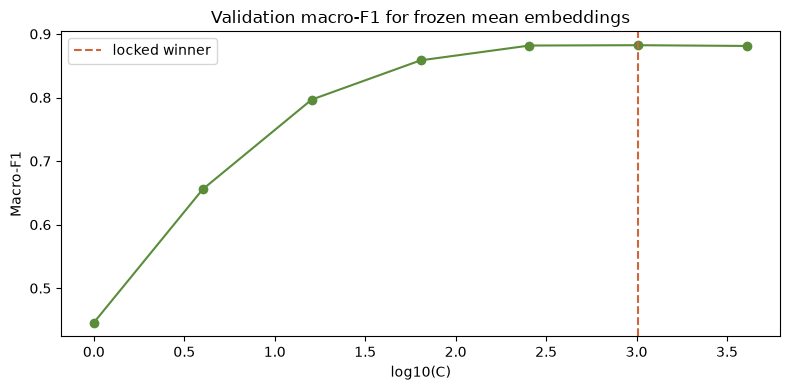

In [5]:
mean_results = candidate_results[candidate_results['pooling'] == 'mean'].sort_values('C')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    np.log10(mean_results['C']),
    mean_results['macro_f1'],
    marker='o',
    color='#5b8c3a',
)
ax.axvline(np.log10(1024), color='#d0643b', linestyle='--', label='locked winner')
ax.set_title('Validation macro-F1 for frozen mean embeddings')
ax.set_xlabel('log10(C)')
ax.set_ylabel('Macro-F1')
ax.legend()
plt.tight_layout()


## MPS extraction evidence

RoBERTa runs on the Mac GPU in inference mode. Logistic regression runs on one CPU thread.
No BANKING77 row exceeded the registered 96-token limit.


In [6]:
pd.DataFrame(
    [
        {
            'split': split_name,
            'rows': details['rows'],
            'device': details['device']['selected'],
            'seconds': details['extraction_seconds'],
            'rows_per_second': details['rows_per_second'],
            'truncated_rows': details['token_length']['truncated_rows'],
            'trainable_encoder_parameters': details['trainable_encoder_parameters'],
        }
        for split_name, details in extraction['splits'].items()
    ]
)


,split,rows,device,seconds,rows_per_second,truncated_rows,trainable_encoder_parameters
0,test,3080,mps,17.055009,180.592104,0,0
1,train,8495,mps,28.921549,293.725618,0,0
2,validation,1501,mps,5.791263,259.183536,0,0


## Locked test comparison

The frozen model is evaluated on the same 3,080 source indices as TF-IDF. Higher log-loss
or confidence quality is not interpreted as calibration evidence in this module.


In [7]:
frozen_metrics = evaluation['test_result']['metrics']
tfidf_metrics = tfidf['test_result']['metrics']
pd.DataFrame(
    {
        'TF-IDF': {name: tfidf_metrics[name] for name in (
            'accuracy', 'macro_f1', 'weighted_f1', 'log_loss', 'top_3_accuracy'
        )},
        'Frozen RoBERTa': {name: frozen_metrics[name] for name in (
            'accuracy', 'macro_f1', 'weighted_f1', 'log_loss', 'top_3_accuracy'
        )},
    }
)


,TF-IDF,Frozen RoBERTa
accuracy,0.905195,0.896104
macro_f1,0.905301,0.896417
weighted_f1,0.905301,0.896417
log_loss,0.496991,0.398984
top_3_accuracy,0.970455,0.971753


In [8]:
paired_summary = {**comparison['correctness'], **comparison['metrics']}
pd.Series(paired_summary, name='paired_test_comparison')


both_correct                          2625.000000
both_wrong                             157.000000
candidate_only_correct                 135.000000
discordant_rows                        298.000000
prediction_disagreements               368.000000
reference_only_correct                 163.000000
candidate_macro_f1                       0.896417
candidate_minus_reference_macro_f1      -0.008884
exact_mcnemar_two_sided_p_value          0.117653
reference_macro_f1                       0.905301
Name: paired_test_comparison, dtype: float64

## Failure analysis


In [9]:
worst_intents = (
    pd.DataFrame.from_dict(frozen_metrics['per_intent'], orient='index')
    .rename_axis('intent')
    .sort_values(['f1', 'recall'])
    .head(10)
)
worst_intents


,f1,precision,recall,support
intent,,,,
balance_not_updated_after_bank_transfer,0.698795,0.674419,0.725,40
pending_transfer,0.753247,0.783784,0.725,40
card_payment_not_recognised,0.784810,0.794872,0.775,40
direct_debit_payment_not_recognised,0.784810,0.794872,0.775,40
card_not_working,0.800000,0.690909,0.950,40
supported_cards_and_currencies,0.809524,0.772727,0.850,40
beneficiary_not_allowed,0.810127,0.820513,0.800,40
fiat_currency_support,0.810127,0.820513,0.800,40
top_up_reverted,0.813953,0.760870,0.875,40


In [10]:
pd.DataFrame(comparison['candidate_advantage_intents']).head(10)


,candidate_correct,candidate_minus_reference_correct,intent,reference_correct,support
0,39,6,why_verify_identity,33,40
1,37,5,verify_my_identity,32,40
2,37,4,disposable_card_limits,33,40
3,38,3,card_not_working,35,40
4,36,3,transfer_timing,33,40
5,36,3,unable_to_verify_identity,33,40
6,31,3,virtual_card_not_working,28,40
7,39,2,declined_cash_withdrawal,37,40
8,34,2,declined_transfer,32,40
9,39,2,getting_spare_card,37,40


## Interpretation

- Frozen RoBERTa reaches **0.8964 macro-F1**, below TF-IDF at **0.9053**.
- The paired exact McNemar p-value is 0.1177; this does not establish equivalence.
- RoBERTa fixes 135 rows that TF-IDF misses, while TF-IDF alone fixes 163 rows.
- The models disagree on 368 rows, indicating useful complementarity for later analysis.
- CLS pooling is unsuitable here; final-layer content-token mean pooling is far stronger.
- Generic frozen representations are not a substitute for domain adaptation.
- Module 5 must evaluate whether LoRA improves semantic separation under the same contract.

To reproduce locally, run python scripts/run_frozen_roberta_baseline.py run --offline.
Use --force-embeddings only when intentionally replacing verified local caches.
